In [22]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import mean_squared_error, r2_score 

In [23]:
# Step 2: Load the Dataset
data = fetch_california_housing(as_frame=True) 
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1) 
print("Dataset Preview:")
display(df.head()) 

# Step 3: Separate Features and Target Variable
X = df.drop("HousePrice", axis=1) 
y = df["HousePrice"] 

# Step 4: Feature Scaling (Critical Step)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42 
)

Dataset Preview:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
# Step 6: Train Multiple Models
models = {
    "Linear Regression": LinearRegression(), # [cite: 100]
    "Ridge Regression": Ridge(alpha=1.0), # [cite: 101]
    "Decision Tree": DecisionTreeRegressor(max_depth=5) # [cite: 102]
}

In [25]:
# Step 7: Model Evaluation and Comparison
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

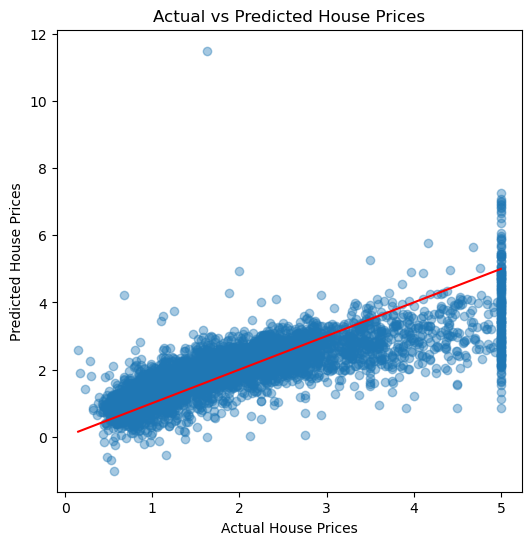

In [26]:
# Step 8: Visual Performance Validation
# We will use Linear Regression as the best_model for this plot example.
best_model = LinearRegression() # [cite: 129]
best_model.fit(X_train, y_train) # [cite: 129]
y_pred = best_model.predict(X_test) # [cite: 130]

plt.figure(figsize=(6,6)) # [cite: 131]
plt.scatter(y_test, y_pred, alpha=0.4) # [cite: 132]
plt.xlabel("Actual House Prices") # [cite: 133]
plt.ylabel("Predicted House Prices") # [cite: 134]
plt.title("Actual vs Predicted House Prices") # [cite: 135]
plt.plot([y_test.min(), y_test.max()], # [cite: 136]
         [y_test.min(), y_test.max()], # [cite: 137]
         color="red") # [cite: 138]
plt.show() # [cite: 139]